## Temporary notebook to test out some code

### Small tutorial about Gymnasium:
check out https://gymnasium.farama.org/introduction/basic_usage/

**Key functions**
- make(): creates an environment
- Env.reset(): resets the environment to an initial state and returns an initial observation
- Env.step(action): takes an action and returns a tuple (observation, reward, done, info)
- Env.render(): renders the environment (optional)

**Env class**: class to represent MDP: start new episodes, take actions visualize agent's current state

*Methods*:
- step(action) -> tuple: - Updates env with actions returning the next agent observation, the reward for taking that actions
- reset() - Resets the environment to an initial state and returns an initial observation
- render() - Renders the environments to help visualise what the agent sees
- close() - Closes the environment and releases resources

*Attributes*:
- action_space - The space of possible actions, ex: Discrete(2) for a binary action space (actions 0/1)
- observation_space - The space of possible observations
- reward_range - The range of possible rewards
- metadata - Additional information about the environment

In [19]:
import random
import numpy as np
import torch
# Run `pip install "gymnasium[classic-control]"` for this example.
import gymnasium as gym


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/marzioformica/miniconda3/envs/rl-project/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/marzioformica/miniconda3/envs/rl-project/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/marzioformica/miniconda3/envs/rl-project/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/marzioformica/miniconda3/envs/rl-project/lib/python3.10/sit

In [ ]:
# Create our training environment - a cart with a pole that needs balancing
env = gym.make("CartPole-v1", render_mode="human")

# Reset environment to start a new episode
observation, info = env.reset()
# observation: what the agent can "see" - cart position, velocity, pole angle, etc.
# info: extra debugging information (usually not needed for basic learning)

print(f"Starting observation: {observation}")
# Example output: [ 0.01234567 -0.00987654  0.02345678  0.01456789]
# [cart_position, cart_velocity, pole_angle, pole_angular_velocity]

episode_over = False
total_reward = 0

while not episode_over:
    # Choose an action: 0 = push cart left, 1 = push cart right
    action = env.action_space.sample()  # Random action for now - real agents will be smarter!

    # Take the action and see what happens
    observation, reward, terminated, truncated, info = env.step(action)

    # reward: +1 for each step the pole stays upright
    # terminated: True if pole falls too far (agent failed)
    # truncated: True if we hit the time limit (500 steps)

    total_reward += reward
    episode_over = terminated or truncated

print(f"Episode finished! Total reward: {total_reward}")
env.close()

Starting observation: [-0.0013699   0.04812768  0.02800485  0.00761347]
Episode finished! Total reward: 22.0


### Test out with a random agent

In [15]:
# -----------------------
# Reproducibility
# -----------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# -----------------------
# Random baseline agent
# (placeholder for DQN/PPO/etc.)
# -----------------------
class RandomAgent:
    """
    A simple agent that takes random actions in the environment.
    This is a baseline for testing our environment and code setup.
    """
    def __init__(self, action_space):
        self.action_space = action_space

    def act(self, state):
        return self.action_space.sample()

In [16]:
# -----------------------
# Run one episode
# -----------------------
def run_episode(env, agent):
    """
    Run a single episode using the given agent and environment, returning the total reward.
    Args:
    - env: The environment to interact with (e.g., CartPole-v1)
    - agent: An instance of an agent that can choose actions based on states
    Returns:
    - total_reward: The cumulative reward obtained during the episode
    """
    # 1. Reset the environment to start a new episode
    state, _ = env.reset()
    done = False
    total_reward = 0

    # 2. Loop until the episode is over (terminated or truncated)
    while not done:
        # Agent chooses an action based on the current state
        action = agent.act(state)
        # Execute the action and observe the next state and reward
        next_state, reward, terminated, truncated, _ = env.step(action)
        # Check if the episode has ended
        done = terminated or truncated
        # Update the current state and accumulate the reward
        state = next_state
        total_reward += reward

    return total_reward

# -----------------------
# Main experiment loop
# -----------------------
def run_experiment(n_episodes=100, seed=0):
    """
    Experiment loop to run multiple episodes with a random agent and collect rewards.
    Args:
    - n_episodes: The number of episodes to run for the experiment
    - seed: The random seed for reproducibility
    Returns:
    - rewards: A list of total rewards obtained from each episode
    """
    set_seed(seed)

    env = gym.make("CartPole-v1")
    env.reset(seed=seed)  # Set environment seed for reproducibility
    env.action_space.seed(seed)

    agent = RandomAgent(env.action_space)

    rewards = []

    for ep in range(n_episodes):
        r = run_episode(env, agent)
        rewards.append(r)
        print(ep, r)

    env.close()
    return rewards

In [20]:
all_rewards = []

for seed in [0, 1, 2]:
    rewards = run_experiment(n_episodes=10, seed=seed)
    all_rewards.append(rewards)

0 22.0
1 29.0
2 18.0
3 41.0
4 19.0
5 30.0
6 21.0
7 12.0
8 16.0
9 26.0
0 40.0
1 12.0
2 35.0
3 14.0
4 15.0
5 22.0
6 20.0
7 29.0
8 44.0
9 10.0
0 21.0
1 24.0
2 11.0
3 39.0
4 14.0
5 36.0
6 12.0
7 32.0
8 44.0
9 26.0


In [ ]:
all_rewards = np.array(all_rewards)
mean_rewards = np.mean(all_rewards, axis=0)
std_rewards = np.std(all_rewards, axis=0)
episodes = np.arange(len(mean_rewards))

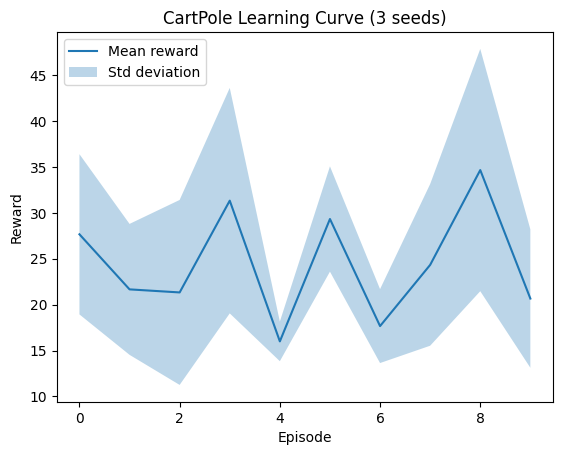

In [ ]:
import matplotlib.pyplot as plt


def plot_learning_curve(episodes, mean_rewards, std_rewards):
    """
    Plot the learning curve with mean rewards and standard deviation.
    Args:
    - episodes (array): Array of episode numbers.
    - mean_rewards (array): Array of mean rewards.
    - std_rewards (array): Array of standard deviations.
    """
    plt.plot(episodes, mean_rewards, label="Mean reward")

    plt.fill_between(
        episodes,
        mean_rewards - std_rewards,
        mean_rewards + std_rewards,
        alpha=0.3,
        label="Std deviation"
    )

    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("CartPole Learning Curve (3 seeds)")
    plt.legend()
    plt.show()